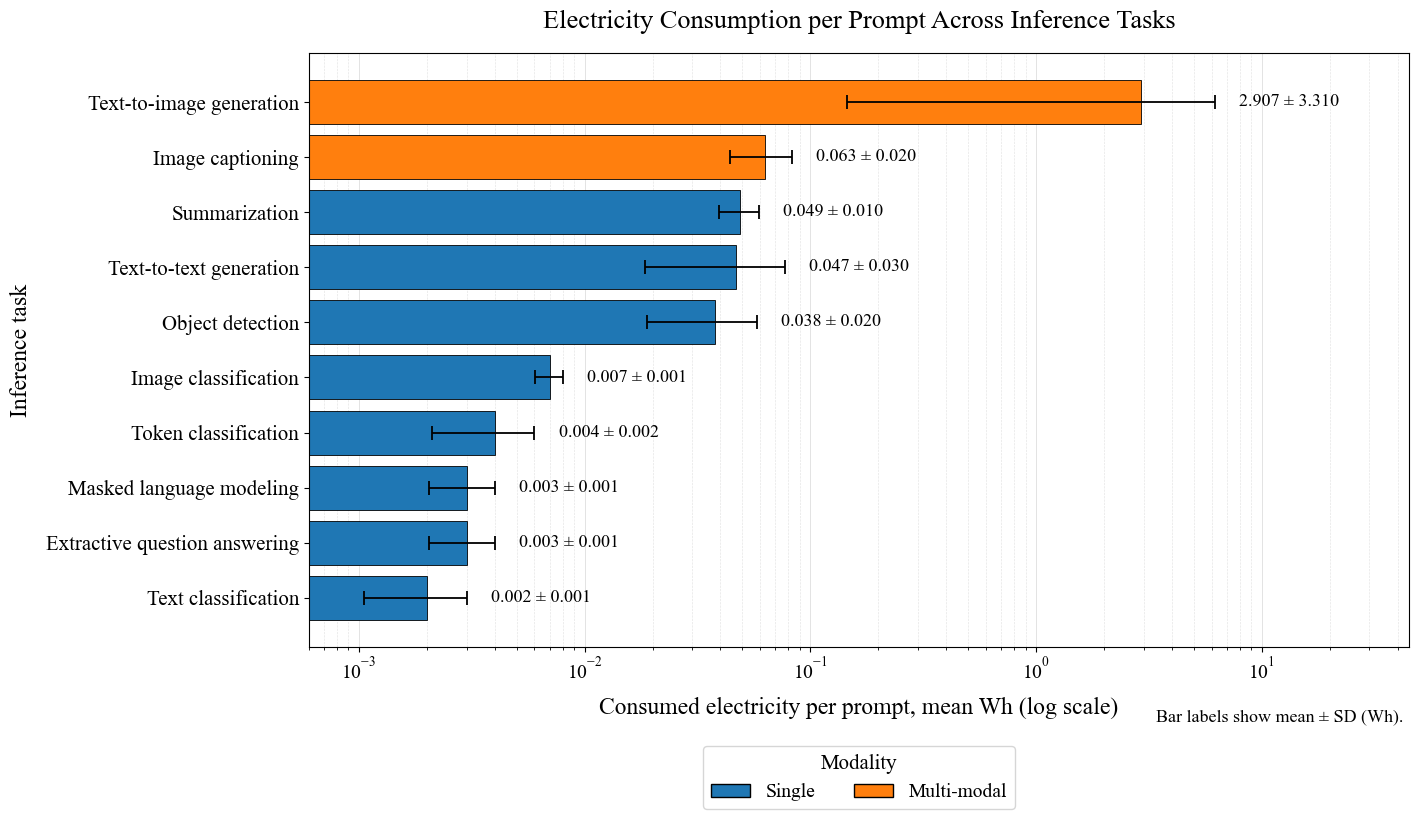

Font used: Times New Roman
electricity_consumption_research_paper_times.png
electricity_consumption_research_paper_times.pdf


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
from pathlib import Path
import matplotlib.patches as mpatches

# -----------------------------
# Data
# -----------------------------
data = [
    ("Single", "Text classification", 0.002, 0.001),
    ("Single", "Extractive question answering", 0.003, 0.001),
    ("Single", "Masked language modeling", 0.003, 0.001),
    ("Single", "Token classification", 0.004, 0.002),
    ("Single", "Image classification", 0.007, 0.001),
    ("Single", "Object detection", 0.038, 0.020),
    ("Single", "Text-to-text generation", 0.047, 0.030),
    ("Single", "Summarization", 0.049, 0.010),
    ("Multi-modal", "Image captioning", 0.063, 0.020),
    ("Multi-modal", "Text-to-image generation", 2.907, 3.310),
]

df = pd.DataFrame(data, columns=["Modality", "Task type", "Mean (Wh)", "Std (Wh)"])
df = df.sort_values("Mean (Wh)", ascending=True)

# -----------------------------
# Font setup
# -----------------------------
available_fonts = {f.name for f in font_manager.fontManager.ttflist}
preferred_font = "Times New Roman" if "Times New Roman" in available_fonts else "Liberation Serif"

plt.rcParams.update({
    "font.family": preferred_font,
    "font.size": 15,
    "axes.titlesize": 19,
    "axes.labelsize": 17,
    "xtick.labelsize": 14,
    "ytick.labelsize": 15,
    "legend.fontsize": 14,
    "legend.title_fontsize": 15,
    "figure.titlesize": 19,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# -----------------------------
# Colors using Matplotlib default cycle
# -----------------------------
default_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
modality_order = ["Single", "Multi-modal"]
color_map = {modality: default_colors[i] for i, modality in enumerate(modality_order)}
bar_colors = df["Modality"].map(color_map)

# For log scale, lower error bars cannot cross zero
lower_error = df[["Mean (Wh)", "Std (Wh)"]].min(axis=1) * 0.95
upper_error = df["Std (Wh)"]

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(15.5, 9))

bars = ax.barh(
    df["Task type"],
    df["Mean (Wh)"],
    xerr=[lower_error, upper_error],
    capsize=5,
    color=bar_colors,
    edgecolor="black",
    linewidth=0.6,
    error_kw={
        "elinewidth": 1.3,
        "capthick": 1.3
    }
)

ax.set_xscale("log")
ax.set_xlim(0.0006, 45)

ax.set_xlabel("Consumed electricity per prompt, mean Wh (log scale)", labelpad=10)
ax.set_ylabel("Inference task", labelpad=10)
ax.set_title("Electricity Consumption per Prompt Across Inference Tasks", pad=18)

ax.grid(axis="x", which="major", linestyle="-", linewidth=0.55, alpha=0.45)
ax.grid(axis="x", which="minor", linestyle="--", linewidth=0.45, alpha=0.35)
ax.set_axisbelow(True)

# Value labels placed beyond right error bars to avoid overlap
for bar, mean, std in zip(bars, df["Mean (Wh)"], df["Std (Wh)"]):
    right_error_end = mean + std
    label_x = right_error_end * 1.28
    ax.text(
        label_x,
        bar.get_y() + bar.get_height() / 2,
        f"{mean:.3f} ± {std:.3f}",
        va="center",
        ha="left",
        fontsize=13
    )

# Legend below chart, outside data area
legend_handles = [
    mpatches.Patch(facecolor=color_map["Single"], edgecolor="black", label="Single"),
    mpatches.Patch(facecolor=color_map["Multi-modal"], edgecolor="black", label="Multi-modal")
]

ax.legend(
    handles=legend_handles,
    title="Modality",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=2,
    frameon=True
)

# Add note for label unit
ax.text(
    0.995,
    -0.105,
    "Bar labels show mean ± SD (Wh).",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=13
)

fig.subplots_adjust(left=0.27, right=0.98, top=0.90, bottom=0.24)

# Save high-resolution outputs
png_path = Path("electricity_consumption_research_paper_times.png")
pdf_path = Path("electricity_consumption_research_paper_times.pdf")

fig.savefig(png_path, dpi=900, bbox_inches="tight")
fig.savefig(pdf_path, bbox_inches="tight")
plt.show()

print(f"Font used: {preferred_font}")
print(png_path)
print(pdf_path)


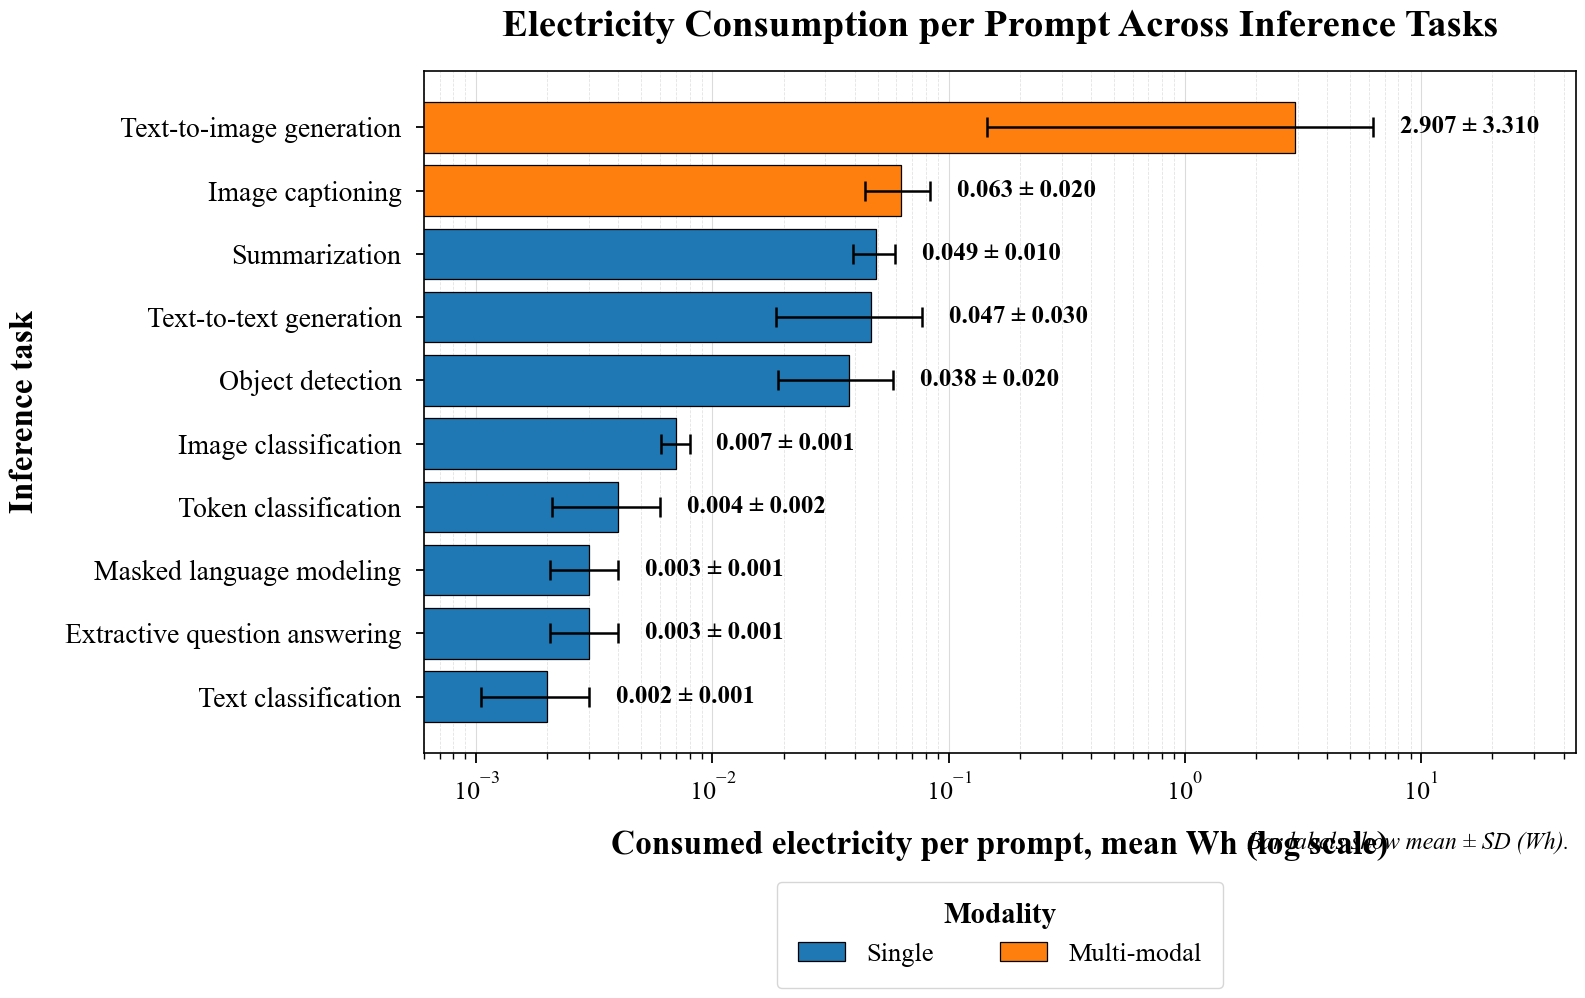

Font used: Times New Roman
PNG saved as: C:\Users\nafem\Downloads\Python Code - Inference Phase\electricity_consumption_large_fonts.png
PDF saved as: C:\Users\nafem\Downloads\Python Code - Inference Phase\electricity_consumption_large_fonts.pdf


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
from pathlib import Path
import matplotlib.patches as mpatches

# -----------------------------
# Data
# -----------------------------
data = [
    ("Single", "Text classification", 0.002, 0.001),
    ("Single", "Extractive question answering", 0.003, 0.001),
    ("Single", "Masked language modeling", 0.003, 0.001),
    ("Single", "Token classification", 0.004, 0.002),
    ("Single", "Image classification", 0.007, 0.001),
    ("Single", "Object detection", 0.038, 0.020),
    ("Single", "Text-to-text generation", 0.047, 0.030),
    ("Single", "Summarization", 0.049, 0.010),
    ("Multi-modal", "Image captioning", 0.063, 0.020),
    ("Multi-modal", "Text-to-image generation", 2.907, 3.310),
]

df = pd.DataFrame(
    data,
    columns=["Modality", "Task type", "Mean (Wh)", "Std (Wh)"]
)

df = df.sort_values("Mean (Wh)", ascending=True)

# -----------------------------
# Font setup
# -----------------------------
available_fonts = {
    font.name for font in font_manager.fontManager.ttflist
}

preferred_font = (
    "Times New Roman"
    if "Times New Roman" in available_fonts
    else "Liberation Serif"
)

# Enlarged font sizes
plt.rcParams.update({
    "font.family": preferred_font,

    # General font
    "font.size": 20,

    # Chart title
    "axes.titlesize": 28,
    "axes.titleweight": "bold",

    # Axis labels
    "axes.labelsize": 24,
    "axes.labelweight": "bold",

    # Tick labels
    "xtick.labelsize": 19,
    "ytick.labelsize": 20,

    # Legend
    "legend.fontsize": 19,
    "legend.title_fontsize": 21,

    # Figure title
    "figure.titlesize": 28,

    # PDF and EPS font compatibility
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# -----------------------------
# Colors
# -----------------------------
default_colors = plt.rcParams[
    "axes.prop_cycle"
].by_key()["color"]

modality_order = ["Single", "Multi-modal"]

color_map = {
    modality: default_colors[i]
    for i, modality in enumerate(modality_order)
}

bar_colors = df["Modality"].map(color_map)

# -----------------------------
# Error-bar values
# -----------------------------
# Prevent lower error bars from crossing zero on the log scale
lower_error = df[["Mean (Wh)", "Std (Wh)"]].min(axis=1) * 0.95
upper_error = df["Std (Wh)"]

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(18, 11))

bars = ax.barh(
    df["Task type"],
    df["Mean (Wh)"],
    xerr=[lower_error, upper_error],
    capsize=7,
    color=bar_colors,
    edgecolor="black",
    linewidth=0.9,
    error_kw={
        "elinewidth": 1.8,
        "capthick": 1.8
    }
)

# Logarithmic x-axis
ax.set_xscale("log")
ax.set_xlim(0.0006, 45)

# Axis labels and title
ax.set_xlabel(
    "Consumed electricity per prompt, mean Wh (log scale)",
    labelpad=18
)

ax.set_ylabel(
    "Inference task",
    labelpad=18
)

ax.set_title(
    "Electricity Consumption per Prompt Across Inference Tasks",
    pad=25
)

# Increase spacing around tick labels
ax.tick_params(
    axis="x",
    which="major",
    pad=8,
    width=1.3,
    length=7
)

ax.tick_params(
    axis="x",
    which="minor",
    width=1.0,
    length=4
)

ax.tick_params(
    axis="y",
    which="major",
    pad=10,
    width=1.3,
    length=6
)

# Grid
ax.grid(
    axis="x",
    which="major",
    linestyle="-",
    linewidth=0.8,
    alpha=0.45
)

ax.grid(
    axis="x",
    which="minor",
    linestyle="--",
    linewidth=0.6,
    alpha=0.35
)

ax.set_axisbelow(True)

# -----------------------------
# Value labels
# -----------------------------
# Labels are positioned beyond the upper error-bar limit
for bar, mean, std in zip(
    bars,
    df["Mean (Wh)"],
    df["Std (Wh)"]
):
    right_error_end = mean + std
    label_x = right_error_end * 1.30

    ax.text(
        label_x,
        bar.get_y() + bar.get_height() / 2,
        f"{mean:.3f} ± {std:.3f}",
        va="center",
        ha="left",
        fontsize=18,
        fontweight="bold"
    )

# -----------------------------
# Legend
# -----------------------------
legend_handles = [
    mpatches.Patch(
        facecolor=color_map["Single"],
        edgecolor="black",
        linewidth=0.9,
        label="Single"
    ),
    mpatches.Patch(
        facecolor=color_map["Multi-modal"],
        edgecolor="black",
        linewidth=0.9,
        label="Multi-modal"
    )
]

legend = ax.legend(
    handles=legend_handles,
    title="Modality",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.17),
    ncol=2,
    frameon=True,
    borderpad=0.8,
    handlelength=1.8,
    columnspacing=2.5
)

legend.get_title().set_fontweight("bold")

# -----------------------------
# Explanatory note
# -----------------------------
ax.text(
    0.995,
    -0.115,
    "Bar labels show mean ± SD (Wh).",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=17,
    fontstyle="italic"
)

# Make chart border slightly stronger
for spine in ax.spines.values():
    spine.set_linewidth(1.2)

# Adjust margins for larger fonts
fig.subplots_adjust(
    left=0.34,
    right=0.98,
    top=0.89,
    bottom=0.27
)

# -----------------------------
# Save outputs
# -----------------------------
png_path = Path(
    "electricity_consumption_large_fonts.png"
)

pdf_path = Path(
    "electricity_consumption_large_fonts.pdf"
)

fig.savefig(
    png_path,
    dpi=900,
    bbox_inches="tight",
    facecolor="white"
)

fig.savefig(
    pdf_path,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print(f"Font used: {preferred_font}")
print(f"PNG saved as: {png_path.resolve()}")
print(f"PDF saved as: {pdf_path.resolve()}")

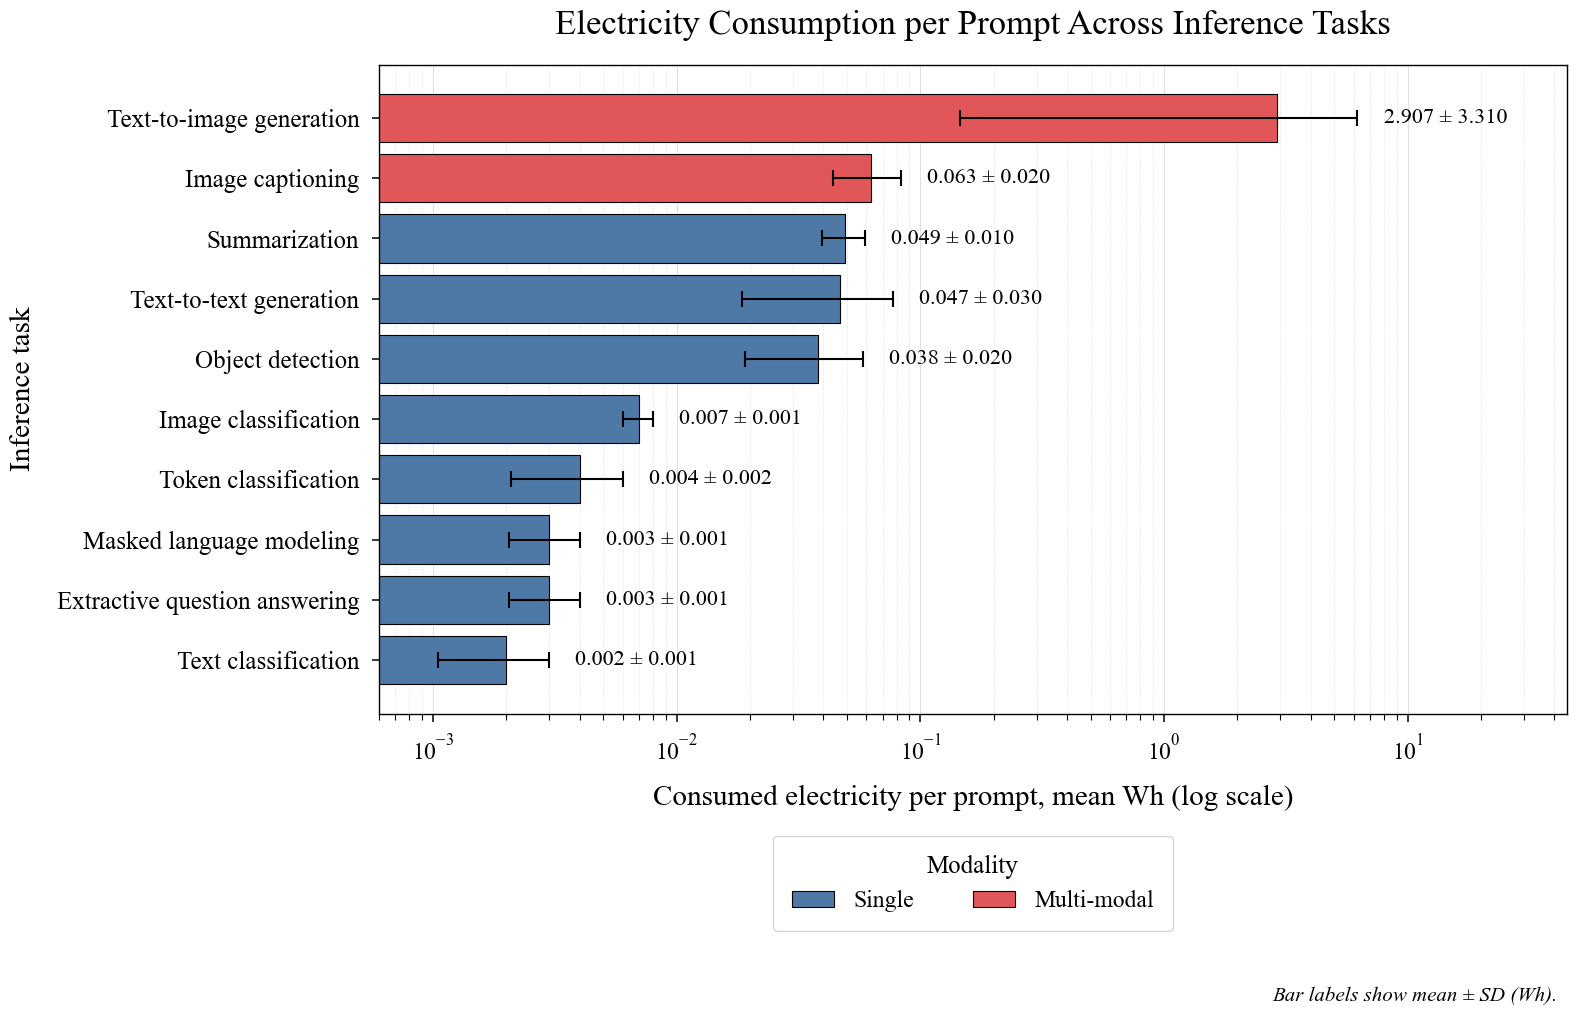

Font used: Times New Roman
PNG saved as: C:\Users\nafem\Downloads\Python Code - Inference Phase\electricity_consumption_updated_colors.png
PDF saved as: C:\Users\nafem\Downloads\Python Code - Inference Phase\electricity_consumption_updated_colors.pdf


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
from pathlib import Path
import matplotlib.patches as mpatches

# -----------------------------
# Data
# -----------------------------
data = [
    ("Single", "Text classification", 0.002, 0.001),
    ("Single", "Extractive question answering", 0.003, 0.001),
    ("Single", "Masked language modeling", 0.003, 0.001),
    ("Single", "Token classification", 0.004, 0.002),
    ("Single", "Image classification", 0.007, 0.001),
    ("Single", "Object detection", 0.038, 0.020),
    ("Single", "Text-to-text generation", 0.047, 0.030),
    ("Single", "Summarization", 0.049, 0.010),
    ("Multi-modal", "Image captioning", 0.063, 0.020),
    ("Multi-modal", "Text-to-image generation", 2.907, 3.310),
]

df = pd.DataFrame(
    data,
    columns=["Modality", "Task type", "Mean (Wh)", "Std (Wh)"]
)

df = df.sort_values("Mean (Wh)", ascending=True)

# -----------------------------
# Font setup
# -----------------------------
available_fonts = {
    font.name for font in font_manager.fontManager.ttflist
}

preferred_font = (
    "Times New Roman"
    if "Times New Roman" in available_fonts
    else "Liberation Serif"
)

plt.rcParams.update({
    "font.family": preferred_font,
    "font.size": 18,

    # No bold formatting
    "axes.titleweight": "normal",
    "axes.labelweight": "normal",

    "axes.titlesize": 25,
    "axes.labelsize": 21,
    "xtick.labelsize": 17,
    "ytick.labelsize": 18,
    "legend.fontsize": 17,
    "legend.title_fontsize": 18,

    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# -----------------------------
# New bar colors
# -----------------------------
color_map = {
    "Single": "#4E79A7",       # Muted blue
    "Multi-modal": "#E15759"   # Muted coral red
}

bar_colors = df["Modality"].map(color_map)

# -----------------------------
# Error-bar values
# -----------------------------
# Prevent lower error bars from crossing zero on the log scale
lower_error = (
    df[["Mean (Wh)", "Std (Wh)"]]
    .min(axis=1)
    * 0.95
)

upper_error = df["Std (Wh)"]

# -----------------------------
# Create plot
# -----------------------------
fig, ax = plt.subplots(figsize=(18, 11))

bars = ax.barh(
    df["Task type"],
    df["Mean (Wh)"],
    xerr=[lower_error, upper_error],
    capsize=6,
    color=bar_colors,
    edgecolor="black",
    linewidth=0.8,
    error_kw={
        "elinewidth": 1.5,
        "capthick": 1.5
    }
)

# -----------------------------
# Axis configuration
# -----------------------------
ax.set_xscale("log")
ax.set_xlim(0.0006, 45)

ax.set_xlabel(
    "Consumed electricity per prompt, mean Wh (log scale)",
    labelpad=15,
    fontweight="normal"
)

ax.set_ylabel(
    "Inference task",
    labelpad=15,
    fontweight="normal"
)

ax.set_title(
    "Electricity Consumption per Prompt Across Inference Tasks",
    pad=22,
    fontweight="normal"
)

# Tick styling
ax.tick_params(
    axis="x",
    which="major",
    pad=8,
    length=6,
    width=1.1
)

ax.tick_params(
    axis="x",
    which="minor",
    length=4,
    width=0.8
)

ax.tick_params(
    axis="y",
    which="major",
    pad=9,
    length=5,
    width=1.1
)

# -----------------------------
# Grid
# -----------------------------
ax.grid(
    axis="x",
    which="major",
    linestyle="-",
    linewidth=0.7,
    alpha=0.40
)

ax.grid(
    axis="x",
    which="minor",
    linestyle="--",
    linewidth=0.5,
    alpha=0.30
)

ax.set_axisbelow(True)

# -----------------------------
# Value labels
# -----------------------------
for bar, mean, std in zip(
    bars,
    df["Mean (Wh)"],
    df["Std (Wh)"]
):
    right_error_end = mean + std
    label_x = right_error_end * 1.28

    ax.text(
        label_x,
        bar.get_y() + bar.get_height() / 2,
        f"{mean:.3f} ± {std:.3f}",
        va="center",
        ha="left",
        fontsize=16,
        fontweight="normal"
    )

# -----------------------------
# Legend
# -----------------------------
legend_handles = [
    mpatches.Patch(
        facecolor=color_map["Single"],
        edgecolor="black",
        linewidth=0.8,
        label="Single"
    ),
    mpatches.Patch(
        facecolor=color_map["Multi-modal"],
        edgecolor="black",
        linewidth=0.8,
        label="Multi-modal"
    )
]

legend = ax.legend(
    handles=legend_handles,
    title="Modality",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.17),
    ncol=2,
    frameon=True,
    borderpad=0.8,
    handlelength=1.8,
    columnspacing=2.5
)

# Ensure legend title is not bold
legend.get_title().set_fontweight("normal")

# -----------------------------
# Explanatory note
# -----------------------------
# Positioned separately at the bottom-right of the figure
fig.text(
    0.975,
    0.035,
    "Bar labels show mean ± SD (Wh).",
    ha="right",
    va="bottom",
    fontsize=15,
    fontstyle="italic",
    fontweight="normal"
)

# -----------------------------
# Border styling
# -----------------------------
for spine in ax.spines.values():
    spine.set_linewidth(1.0)

# More bottom space prevents overlap
fig.subplots_adjust(
    left=0.32,
    right=0.98,
    top=0.89,
    bottom=0.30
)

# -----------------------------
# Save outputs
# -----------------------------
png_path = Path(
    "electricity_consumption_updated_colors.png"
)

pdf_path = Path(
    "electricity_consumption_updated_colors.pdf"
)

fig.savefig(
    png_path,
    dpi=900,
    bbox_inches="tight",
    facecolor="white"
)

fig.savefig(
    pdf_path,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print(f"Font used: {preferred_font}")
print(f"PNG saved as: {png_path.resolve()}")
print(f"PDF saved as: {pdf_path.resolve()}")

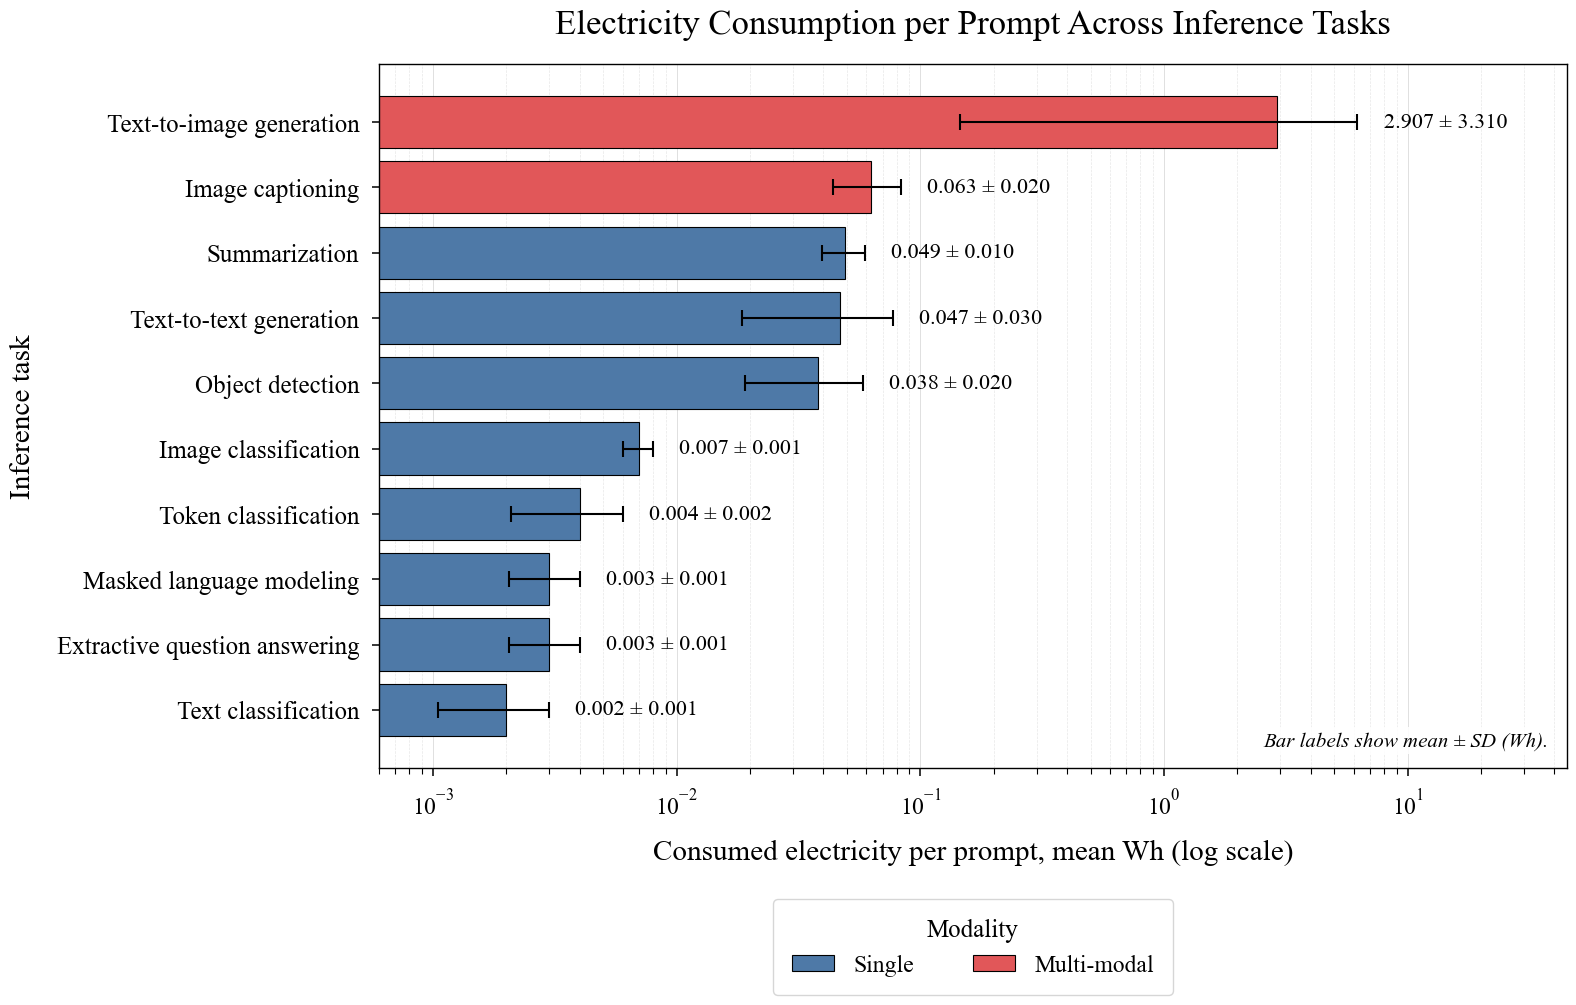

Font used: Times New Roman
PNG saved as: C:\Users\nafem\Downloads\Python Code - Inference Phase\electricity_consumption_final.png
PDF saved as: C:\Users\nafem\Downloads\Python Code - Inference Phase\electricity_consumption_final.pdf


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
from pathlib import Path
import matplotlib.patches as mpatches

# -----------------------------
# Data
# -----------------------------
data = [
    ("Single", "Text classification", 0.002, 0.001),
    ("Single", "Extractive question answering", 0.003, 0.001),
    ("Single", "Masked language modeling", 0.003, 0.001),
    ("Single", "Token classification", 0.004, 0.002),
    ("Single", "Image classification", 0.007, 0.001),
    ("Single", "Object detection", 0.038, 0.020),
    ("Single", "Text-to-text generation", 0.047, 0.030),
    ("Single", "Summarization", 0.049, 0.010),
    ("Multi-modal", "Image captioning", 0.063, 0.020),
    ("Multi-modal", "Text-to-image generation", 2.907, 3.310),
]

df = pd.DataFrame(
    data,
    columns=[
        "Modality",
        "Task type",
        "Mean (Wh)",
        "Std (Wh)"
    ]
)

# Sort values from lowest to highest
df = df.sort_values(
    "Mean (Wh)",
    ascending=True
).reset_index(drop=True)

# -----------------------------
# Font setup
# -----------------------------
available_fonts = {
    font.name
    for font in font_manager.fontManager.ttflist
}

preferred_font = (
    "Times New Roman"
    if "Times New Roman" in available_fonts
    else "Liberation Serif"
)

plt.rcParams.update({
    "font.family": preferred_font,
    "font.size": 18,

    # Title
    "axes.titlesize": 25,
    "axes.titleweight": "normal",

    # Axis labels
    "axes.labelsize": 21,
    "axes.labelweight": "normal",

    # Tick labels
    "xtick.labelsize": 17,
    "ytick.labelsize": 18,

    # Legend
    "legend.fontsize": 17,
    "legend.title_fontsize": 18,

    # Maintain editable fonts in PDF
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# -----------------------------
# Bar colors
# -----------------------------
color_map = {
    "Single": "#4E79A7",       # Muted blue
    "Multi-modal": "#E15759"   # Muted coral
}

bar_colors = df["Modality"].map(color_map)

# -----------------------------
# Error-bar values
# -----------------------------
# Prevent lower error bars from crossing zero
# because the x-axis uses a logarithmic scale
lower_error = (
    df[["Mean (Wh)", "Std (Wh)"]]
    .min(axis=1)
    * 0.95
)

upper_error = df["Std (Wh)"]

# -----------------------------
# Create figure
# -----------------------------
fig, ax = plt.subplots(
    figsize=(18, 11)
)

# -----------------------------
# Horizontal bars
# -----------------------------
bars = ax.barh(
    df["Task type"],
    df["Mean (Wh)"],
    xerr=[
        lower_error,
        upper_error
    ],
    capsize=6,
    color=bar_colors,
    edgecolor="black",
    linewidth=0.8,
    error_kw={
        "elinewidth": 1.5,
        "capthick": 1.5
    }
)

# -----------------------------
# Axis configuration
# -----------------------------
ax.set_xscale("log")
ax.set_xlim(0.0006, 45)

ax.set_xlabel(
    "Consumed electricity per prompt, mean Wh (log scale)",
    labelpad=15,
    fontweight="normal"
)

ax.set_ylabel(
    "Inference task",
    labelpad=15,
    fontweight="normal"
)

ax.set_title(
    "Electricity Consumption per Prompt Across Inference Tasks",
    pad=22,
    fontweight="normal"
)

# -----------------------------
# Tick appearance
# -----------------------------
ax.tick_params(
    axis="x",
    which="major",
    pad=8,
    length=6,
    width=1.1
)

ax.tick_params(
    axis="x",
    which="minor",
    length=4,
    width=0.8
)

ax.tick_params(
    axis="y",
    which="major",
    pad=9,
    length=5,
    width=1.1
)

# Ensure all tick labels use normal font weight
for label in ax.get_xticklabels():
    label.set_fontweight("normal")

for label in ax.get_yticklabels():
    label.set_fontweight("normal")

# -----------------------------
# Grid
# -----------------------------
ax.grid(
    axis="x",
    which="major",
    linestyle="-",
    linewidth=0.7,
    alpha=0.40
)

ax.grid(
    axis="x",
    which="minor",
    linestyle="--",
    linewidth=0.5,
    alpha=0.30
)

ax.set_axisbelow(True)

# -----------------------------
# Bar value labels
# -----------------------------
for bar, mean, std in zip(
    bars,
    df["Mean (Wh)"],
    df["Std (Wh)"]
):
    # Position label beyond the upper error bar
    right_error_end = mean + std
    label_x = right_error_end * 1.28

    ax.text(
        label_x,
        bar.get_y() + bar.get_height() / 2,
        f"{mean:.3f} ± {std:.3f}",
        va="center",
        ha="left",
        fontsize=16,
        fontweight="normal"
    )

# -----------------------------
# Legend
# -----------------------------
legend_handles = [
    mpatches.Patch(
        facecolor=color_map["Single"],
        edgecolor="black",
        linewidth=0.8,
        label="Single"
    ),
    mpatches.Patch(
        facecolor=color_map["Multi-modal"],
        edgecolor="black",
        linewidth=0.8,
        label="Multi-modal"
    )
]

legend = ax.legend(
    handles=legend_handles,
    title="Modality",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.17),
    ncol=2,
    frameon=True,
    borderpad=0.8,
    handlelength=1.8,
    columnspacing=2.5
)

# Remove bold formatting from legend
legend.get_title().set_fontweight("normal")

for text in legend.get_texts():
    text.set_fontweight("normal")

# -----------------------------
# Note inside the plot
# Bottom-right corner
# -----------------------------
ax.text(
    0.985,
    0.025,
    "Bar labels show mean ± SD (Wh).",
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=15,
    fontstyle="italic",
    fontweight="normal",
    zorder=10,
    bbox={
        "facecolor": "white",
        "edgecolor": "none",
        "alpha": 0.88,
        "pad": 3
    }
)

# -----------------------------
# Plot border
# -----------------------------
for spine in ax.spines.values():
    spine.set_linewidth(1.0)

# -----------------------------
# Figure spacing
# -----------------------------
fig.subplots_adjust(
    left=0.32,
    right=0.98,
    top=0.89,
    bottom=0.25
)

# -----------------------------
# Save outputs
# -----------------------------
png_path = Path(
    "electricity_consumption_final.png"
)

pdf_path = Path(
    "electricity_consumption_final.pdf"
)

fig.savefig(
    png_path,
    dpi=900,
    bbox_inches="tight",
    facecolor="white"
)

fig.savefig(
    pdf_path,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print(f"Font used: {preferred_font}")
print(f"PNG saved as: {png_path.resolve()}")
print(f"PDF saved as: {pdf_path.resolve()}")

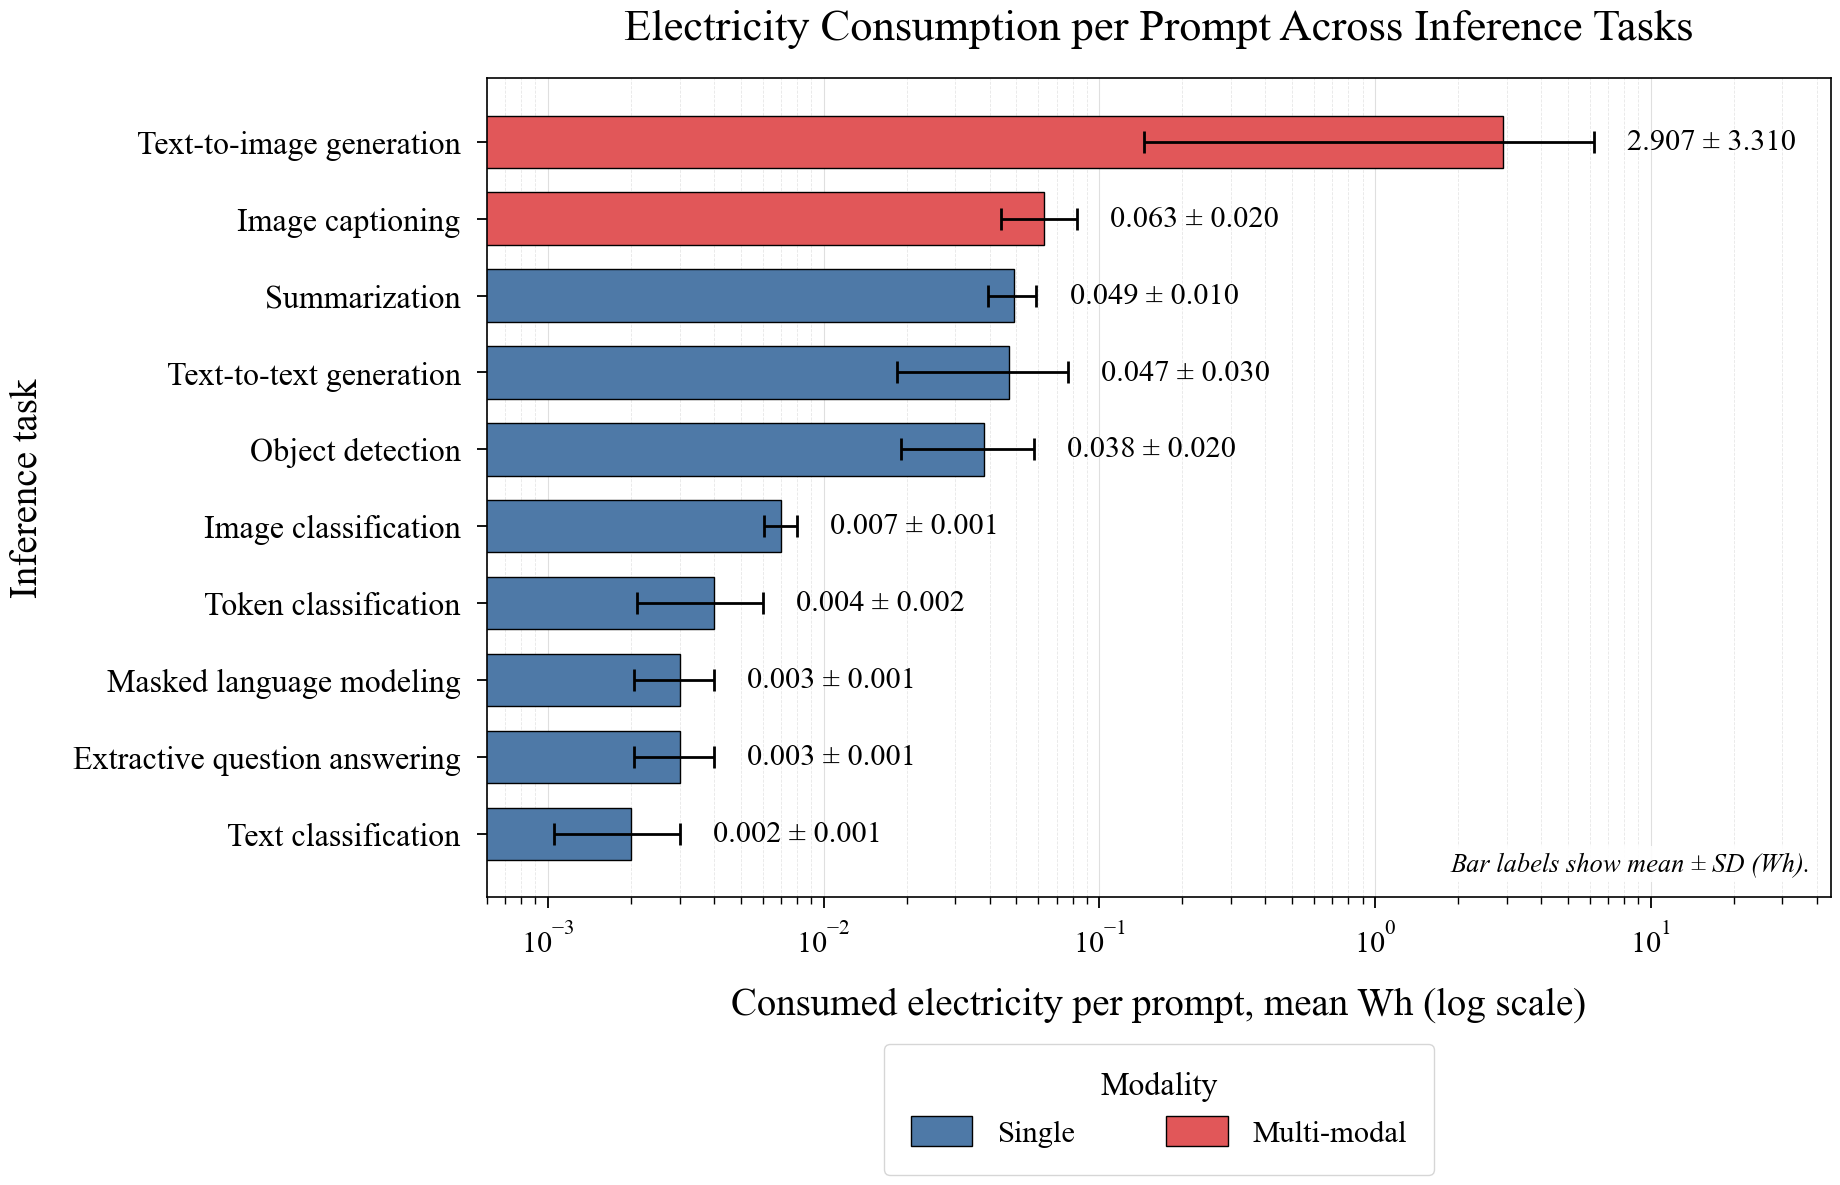

Font used: Times New Roman
PNG saved as: C:\Users\nafem\Downloads\Python Code - Inference Phase\electricity_consumption_extra_large_text.png
PDF saved as: C:\Users\nafem\Downloads\Python Code - Inference Phase\electricity_consumption_extra_large_text.pdf


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
from pathlib import Path
import matplotlib.patches as mpatches

# -----------------------------
# Data
# -----------------------------
data = [
    ("Single", "Text classification", 0.002, 0.001),
    ("Single", "Extractive question answering", 0.003, 0.001),
    ("Single", "Masked language modeling", 0.003, 0.001),
    ("Single", "Token classification", 0.004, 0.002),
    ("Single", "Image classification", 0.007, 0.001),
    ("Single", "Object detection", 0.038, 0.020),
    ("Single", "Text-to-text generation", 0.047, 0.030),
    ("Single", "Summarization", 0.049, 0.010),
    ("Multi-modal", "Image captioning", 0.063, 0.020),
    ("Multi-modal", "Text-to-image generation", 2.907, 3.310),
]

df = pd.DataFrame(
    data,
    columns=[
        "Modality",
        "Task type",
        "Mean (Wh)",
        "Std (Wh)"
    ]
)

df = df.sort_values(
    "Mean (Wh)",
    ascending=True
).reset_index(drop=True)

# -----------------------------
# Font setup
# -----------------------------
available_fonts = {
    font.name
    for font in font_manager.fontManager.ttflist
}

preferred_font = (
    "Times New Roman"
    if "Times New Roman" in available_fonts
    else "Liberation Serif"
)

plt.rcParams.update({
    "font.family": preferred_font,

    # Enlarged overall font
    "font.size": 23,

    # Chart title
    "axes.titlesize": 32,
    "axes.titleweight": "normal",

    # Axis labels
    "axes.labelsize": 28,
    "axes.labelweight": "normal",

    # Tick labels
    "xtick.labelsize": 22,
    "ytick.labelsize": 23,

    # Legend
    "legend.fontsize": 22,
    "legend.title_fontsize": 23,

    # Editable fonts in PDF
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# -----------------------------
# Bar colors
# -----------------------------
color_map = {
    "Single": "#4E79A7",
    "Multi-modal": "#E15759"
}

bar_colors = df["Modality"].map(color_map)

# -----------------------------
# Error-bar values
# -----------------------------
# Prevent the lower error bars from crossing zero
# because the horizontal axis uses a logarithmic scale.
lower_error = (
    df[["Mean (Wh)", "Std (Wh)"]]
    .min(axis=1)
    * 0.95
)

upper_error = df["Std (Wh)"]

# -----------------------------
# Create figure
# -----------------------------
fig, ax = plt.subplots(
    figsize=(21, 13)
)

# -----------------------------
# Horizontal bar chart
# -----------------------------
bars = ax.barh(
    df["Task type"],
    df["Mean (Wh)"],
    xerr=[
        lower_error,
        upper_error
    ],
    height=0.68,
    capsize=8,
    color=bar_colors,
    edgecolor="black",
    linewidth=1.0,
    error_kw={
        "elinewidth": 2.0,
        "capthick": 2.0
    }
)

# -----------------------------
# Axis configuration
# -----------------------------
ax.set_xscale("log")
ax.set_xlim(0.0006, 45)

ax.set_xlabel(
    "Consumed electricity per prompt, mean Wh (log scale)",
    labelpad=20,
    fontweight="normal"
)

ax.set_ylabel(
    "Inference task",
    labelpad=20,
    fontweight="normal"
)

ax.set_title(
    "Electricity Consumption per Prompt Across Inference Tasks",
    pad=28,
    fontweight="normal"
)

# -----------------------------
# Tick appearance
# -----------------------------
ax.tick_params(
    axis="x",
    which="major",
    pad=10,
    length=8,
    width=1.3
)

ax.tick_params(
    axis="x",
    which="minor",
    length=5,
    width=1.0
)

ax.tick_params(
    axis="y",
    which="major",
    pad=12,
    length=7,
    width=1.3
)

# Make sure tick labels are not bold
for label in ax.get_xticklabels():
    label.set_fontweight("normal")

for label in ax.get_yticklabels():
    label.set_fontweight("normal")

# -----------------------------
# Grid lines
# -----------------------------
ax.grid(
    axis="x",
    which="major",
    linestyle="-",
    linewidth=0.8,
    alpha=0.40
)

ax.grid(
    axis="x",
    which="minor",
    linestyle="--",
    linewidth=0.6,
    alpha=0.30
)

ax.set_axisbelow(True)

# -----------------------------
# Enlarged mean ± SD labels
# -----------------------------
for bar, mean, std in zip(
    bars,
    df["Mean (Wh)"],
    df["Std (Wh)"]
):
    # Place each label beyond the right error-bar endpoint
    right_error_end = mean + std
    label_x = right_error_end * 1.32

    ax.text(
        label_x,
        bar.get_y() + bar.get_height() / 2,
        f"{mean:.3f} ± {std:.3f}",
        va="center",
        ha="left",

        # Enlarged bar-label font
        fontsize=22,

        fontweight="normal",
        clip_on=False
    )

# -----------------------------
# Legend
# -----------------------------
legend_handles = [
    mpatches.Patch(
        facecolor=color_map["Single"],
        edgecolor="black",
        linewidth=1.0,
        label="Single"
    ),
    mpatches.Patch(
        facecolor=color_map["Multi-modal"],
        edgecolor="black",
        linewidth=1.0,
        label="Multi-modal"
    )
]

legend = ax.legend(
    handles=legend_handles,
    title="Modality",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.16),
    ncol=2,
    frameon=True,
    borderpad=0.9,
    handlelength=2.0,
    handleheight=1.1,
    columnspacing=3.0
)

legend.get_title().set_fontweight("normal")

for text in legend.get_texts():
    text.set_fontweight("normal")

# -----------------------------
# Note inside the plotting area
# -----------------------------
ax.text(
    0.985,
    0.025,
    "Bar labels show mean ± SD (Wh).",
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=19,
    fontstyle="italic",
    fontweight="normal",
    zorder=10,
    bbox={
        "facecolor": "white",
        "edgecolor": "none",
        "alpha": 0.88,
        "pad": 4
    }
)

# -----------------------------
# Plot border
# -----------------------------
for spine in ax.spines.values():
    spine.set_linewidth(1.2)

# -----------------------------
# Figure spacing
# -----------------------------
fig.subplots_adjust(
    left=0.34,
    right=0.98,
    top=0.88,
    bottom=0.25
)

# -----------------------------
# Save outputs
# -----------------------------
png_path = Path(
    "electricity_consumption_extra_large_text.png"
)

pdf_path = Path(
    "electricity_consumption_extra_large_text.pdf"
)

fig.savefig(
    png_path,
    dpi=900,
    bbox_inches="tight",
    facecolor="white"
)

fig.savefig(
    pdf_path,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print(f"Font used: {preferred_font}")
print(f"PNG saved as: {png_path.resolve()}")
print(f"PDF saved as: {pdf_path.resolve()}")

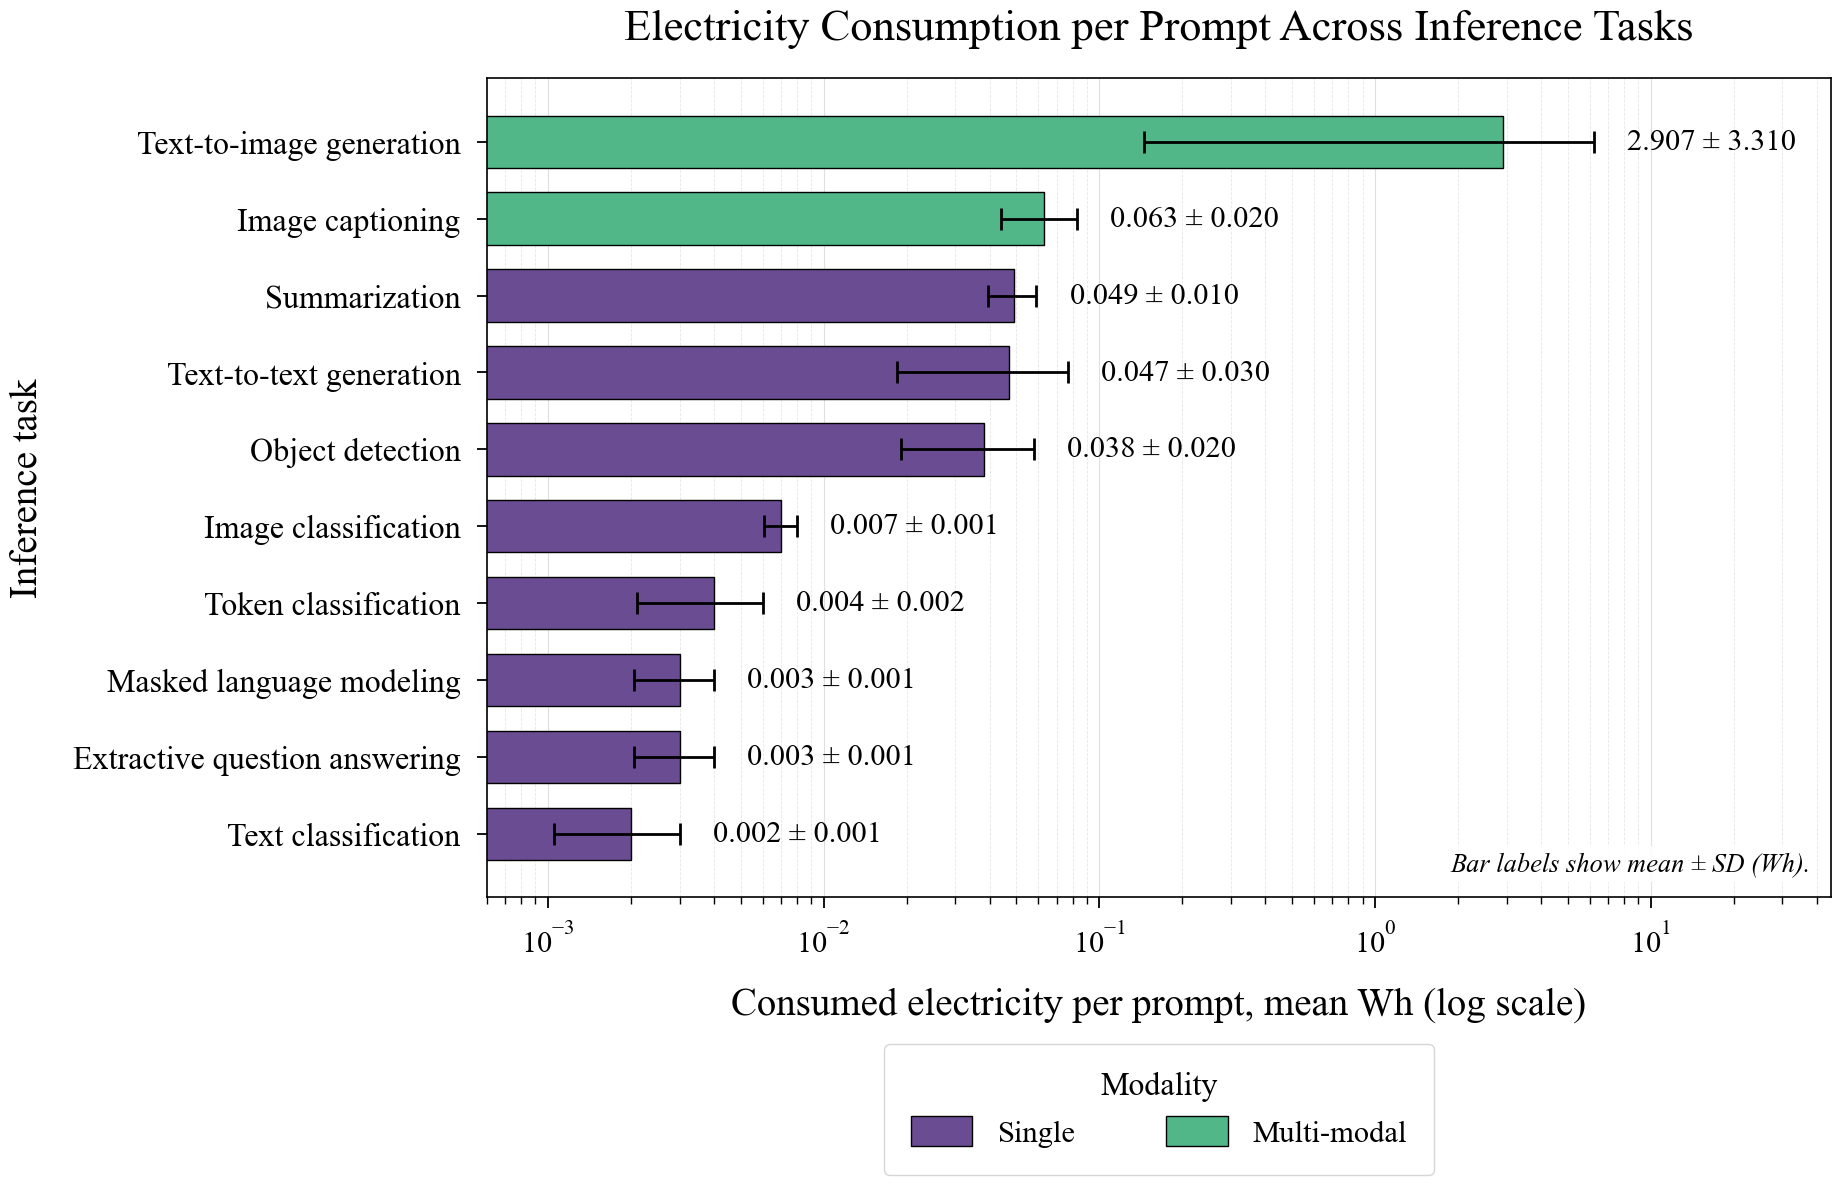

Font used: Times New Roman
PNG saved as: C:\Users\nafem\Downloads\Python Code - Inference Phase\electricity_consumption_extra_large_text.png
PDF saved as: C:\Users\nafem\Downloads\Python Code - Inference Phase\electricity_consumption_extra_large_text.pdf


In [17]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
from pathlib import Path
import matplotlib.patches as mpatches

# -----------------------------
# Data
# -----------------------------
data = [
    ("Single", "Text classification", 0.002, 0.001),
    ("Single", "Extractive question answering", 0.003, 0.001),
    ("Single", "Masked language modeling", 0.003, 0.001),
    ("Single", "Token classification", 0.004, 0.002),
    ("Single", "Image classification", 0.007, 0.001),
    ("Single", "Object detection", 0.038, 0.020),
    ("Single", "Text-to-text generation", 0.047, 0.030),
    ("Single", "Summarization", 0.049, 0.010),
    ("Multi-modal", "Image captioning", 0.063, 0.020),
    ("Multi-modal", "Text-to-image generation", 2.907, 3.310),
]

df = pd.DataFrame(
    data,
    columns=[
        "Modality",
        "Task type",
        "Mean (Wh)",
        "Std (Wh)"
    ]
)

df = df.sort_values(
    "Mean (Wh)",
    ascending=True
).reset_index(drop=True)

# -----------------------------
# Font setup
# -----------------------------
available_fonts = {
    font.name
    for font in font_manager.fontManager.ttflist
}

preferred_font = (
    "Times New Roman"
    if "Times New Roman" in available_fonts
    else "Liberation Serif"
)

plt.rcParams.update({
    "font.family": preferred_font,

    # Enlarged overall font
    "font.size": 23,

    # Chart title
    "axes.titlesize": 32,
    "axes.titleweight": "normal",

    # Axis labels
    "axes.labelsize": 28,
    "axes.labelweight": "normal",

    # Tick labels
    "xtick.labelsize": 22,
    "ytick.labelsize": 23,

    # Legend
    "legend.fontsize": 22,
    "legend.title_fontsize": 23,

    # Editable fonts in PDF
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})













# -----------------------------
# Bar colors
# -----------------------------
color_map = {
    "Single": "#6A4C93",
    "Multi-modal": "#52B788"
}
















bar_colors = df["Modality"].map(color_map)

# -----------------------------
# Error-bar values
# -----------------------------
# Prevent the lower error bars from crossing zero
# because the horizontal axis uses a logarithmic scale.
lower_error = (
    df[["Mean (Wh)", "Std (Wh)"]]
    .min(axis=1)
    * 0.95
)

upper_error = df["Std (Wh)"]

# -----------------------------
# Create figure
# -----------------------------
fig, ax = plt.subplots(
    figsize=(21, 13)
)

# -----------------------------
# Horizontal bar chart
# -----------------------------
bars = ax.barh(
    df["Task type"],
    df["Mean (Wh)"],
    xerr=[
        lower_error,
        upper_error
    ],
    height=0.68,
    capsize=8,
    color=bar_colors,
    edgecolor="black",
    linewidth=1.0,
    error_kw={
        "elinewidth": 2.0,
        "capthick": 2.0
    }
)

# -----------------------------
# Axis configuration
# -----------------------------
ax.set_xscale("log")
ax.set_xlim(0.0006, 45)

ax.set_xlabel(
    "Consumed electricity per prompt, mean Wh (log scale)",
    labelpad=20,
    fontweight="normal"
)

ax.set_ylabel(
    "Inference task",
    labelpad=20,
    fontweight="normal"
)

ax.set_title(
    "Electricity Consumption per Prompt Across Inference Tasks",
    pad=28,
    fontweight="normal"
)

# -----------------------------
# Tick appearance
# -----------------------------
ax.tick_params(
    axis="x",
    which="major",
    pad=10,
    length=8,
    width=1.3
)

ax.tick_params(
    axis="x",
    which="minor",
    length=5,
    width=1.0
)

ax.tick_params(
    axis="y",
    which="major",
    pad=12,
    length=7,
    width=1.3
)

# Make sure tick labels are not bold
for label in ax.get_xticklabels():
    label.set_fontweight("normal")

for label in ax.get_yticklabels():
    label.set_fontweight("normal")

# -----------------------------
# Grid lines
# -----------------------------
ax.grid(
    axis="x",
    which="major",
    linestyle="-",
    linewidth=0.8,
    alpha=0.40
)

ax.grid(
    axis="x",
    which="minor",
    linestyle="--",
    linewidth=0.6,
    alpha=0.30
)

ax.set_axisbelow(True)

# -----------------------------
# Enlarged mean ± SD labels
# -----------------------------
for bar, mean, std in zip(
    bars,
    df["Mean (Wh)"],
    df["Std (Wh)"]
):
    # Place each label beyond the right error-bar endpoint
    right_error_end = mean + std
    label_x = right_error_end * 1.32

    ax.text(
        label_x,
        bar.get_y() + bar.get_height() / 2,
        f"{mean:.3f} ± {std:.3f}",
        va="center",
        ha="left",

        # Enlarged bar-label font
        fontsize=22,

        fontweight="normal",
        clip_on=False
    )

# -----------------------------
# Legend
# -----------------------------
legend_handles = [
    mpatches.Patch(
        facecolor=color_map["Single"],
        edgecolor="black",
        linewidth=1.0,
        label="Single"
    ),
    mpatches.Patch(
        facecolor=color_map["Multi-modal"],
        edgecolor="black",
        linewidth=1.0,
        label="Multi-modal"
    )
]

legend = ax.legend(
    handles=legend_handles,
    title="Modality",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.16),
    ncol=2,
    frameon=True,
    borderpad=0.9,
    handlelength=2.0,
    handleheight=1.1,
    columnspacing=3.0
)

legend.get_title().set_fontweight("normal")

for text in legend.get_texts():
    text.set_fontweight("normal")

# -----------------------------
# Note inside the plotting area
# -----------------------------
ax.text(
    0.985,
    0.025,
    "Bar labels show mean ± SD (Wh).",
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=19,
    fontstyle="italic",
    fontweight="normal",
    zorder=10,
    bbox={
        "facecolor": "white",
        "edgecolor": "none",
        "alpha": 0.88,
        "pad": 4
    }
)

# -----------------------------
# Plot border
# -----------------------------
for spine in ax.spines.values():
    spine.set_linewidth(1.2)

# -----------------------------
# Figure spacing
# -----------------------------
fig.subplots_adjust(
    left=0.34,
    right=0.98,
    top=0.88,
    bottom=0.25
)

# -----------------------------
# Save outputs
# -----------------------------
png_path = Path(
    "electricity_consumption_extra_large_text.png"
)

pdf_path = Path(
    "electricity_consumption_extra_large_text.pdf"
)

fig.savefig(
    png_path,
    dpi=900,
    bbox_inches="tight",
    facecolor="white"
)

fig.savefig(
    pdf_path,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print(f"Font used: {preferred_font}")
print(f"PNG saved as: {png_path.resolve()}")
print(f"PDF saved as: {pdf_path.resolve()}")

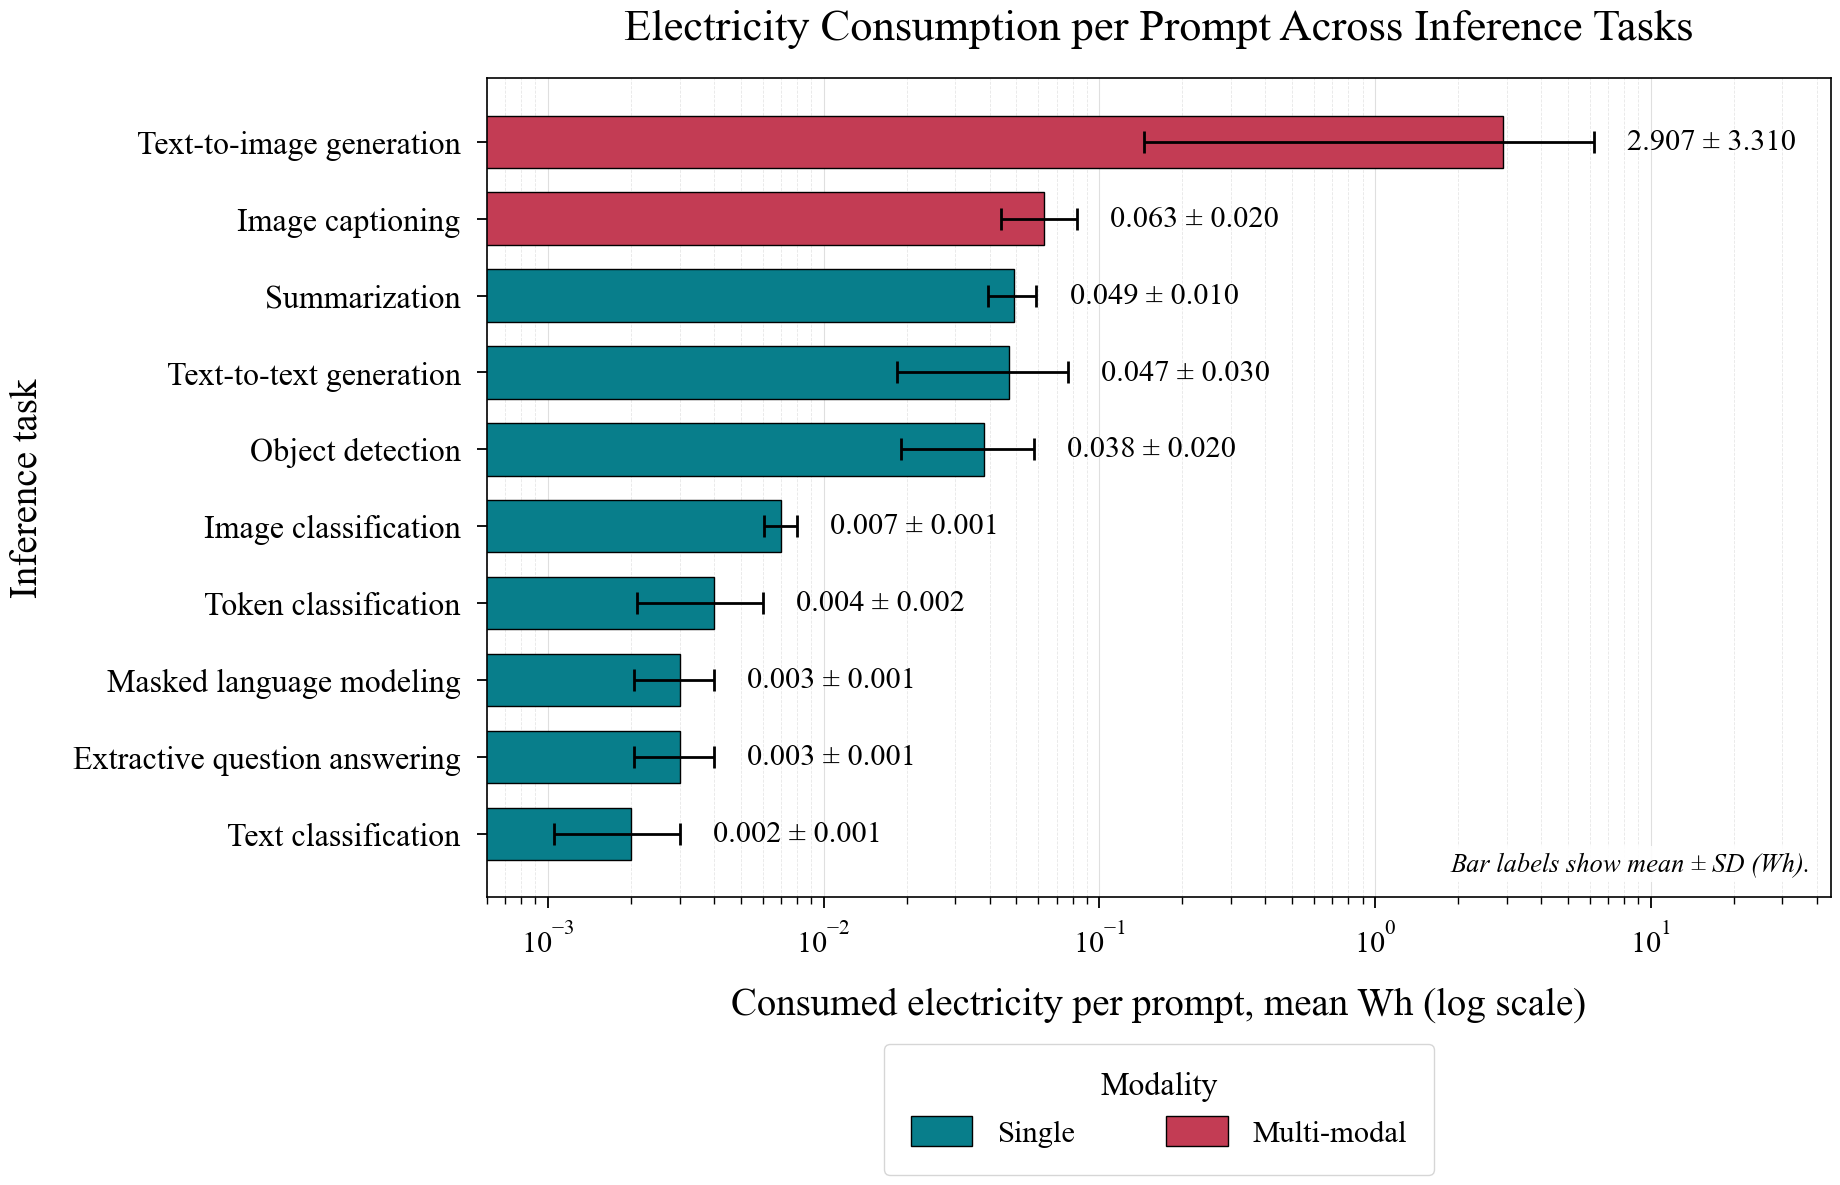

Font used: Times New Roman
PNG saved as: C:\Users\nafem\Downloads\Python Code - Inference Phase\electricity_consumption_extra_large_text.png
PDF saved as: C:\Users\nafem\Downloads\Python Code - Inference Phase\electricity_consumption_extra_large_text.pdf


In [18]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
from pathlib import Path
import matplotlib.patches as mpatches

# -----------------------------
# Data
# -----------------------------
data = [
    ("Single", "Text classification", 0.002, 0.001),
    ("Single", "Extractive question answering", 0.003, 0.001),
    ("Single", "Masked language modeling", 0.003, 0.001),
    ("Single", "Token classification", 0.004, 0.002),
    ("Single", "Image classification", 0.007, 0.001),
    ("Single", "Object detection", 0.038, 0.020),
    ("Single", "Text-to-text generation", 0.047, 0.030),
    ("Single", "Summarization", 0.049, 0.010),
    ("Multi-modal", "Image captioning", 0.063, 0.020),
    ("Multi-modal", "Text-to-image generation", 2.907, 3.310),
]

df = pd.DataFrame(
    data,
    columns=[
        "Modality",
        "Task type",
        "Mean (Wh)",
        "Std (Wh)"
    ]
)

df = df.sort_values(
    "Mean (Wh)",
    ascending=True
).reset_index(drop=True)

# -----------------------------
# Font setup
# -----------------------------
available_fonts = {
    font.name
    for font in font_manager.fontManager.ttflist
}

preferred_font = (
    "Times New Roman"
    if "Times New Roman" in available_fonts
    else "Liberation Serif"
)

plt.rcParams.update({
    "font.family": preferred_font,

    # Enlarged overall font
    "font.size": 23,

    # Chart title
    "axes.titlesize": 32,
    "axes.titleweight": "normal",

    # Axis labels
    "axes.labelsize": 28,
    "axes.labelweight": "normal",

    # Tick labels
    "xtick.labelsize": 22,
    "ytick.labelsize": 23,

    # Legend
    "legend.fontsize": 22,
    "legend.title_fontsize": 23,

    # Editable fonts in PDF
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})













# -----------------------------
# Bar colors
# -----------------------------
color_map = {
    "Single": "#087E8B",
    "Multi-modal": "#C33C54"
}















bar_colors = df["Modality"].map(color_map)

# -----------------------------
# Error-bar values
# -----------------------------
# Prevent the lower error bars from crossing zero
# because the horizontal axis uses a logarithmic scale.
lower_error = (
    df[["Mean (Wh)", "Std (Wh)"]]
    .min(axis=1)
    * 0.95
)

upper_error = df["Std (Wh)"]

# -----------------------------
# Create figure
# -----------------------------
fig, ax = plt.subplots(
    figsize=(21, 13)
)

# -----------------------------
# Horizontal bar chart
# -----------------------------
bars = ax.barh(
    df["Task type"],
    df["Mean (Wh)"],
    xerr=[
        lower_error,
        upper_error
    ],
    height=0.68,
    capsize=8,
    color=bar_colors,
    edgecolor="black",
    linewidth=1.0,
    error_kw={
        "elinewidth": 2.0,
        "capthick": 2.0
    }
)

# -----------------------------
# Axis configuration
# -----------------------------
ax.set_xscale("log")
ax.set_xlim(0.0006, 45)

ax.set_xlabel(
    "Consumed electricity per prompt, mean Wh (log scale)",
    labelpad=20,
    fontweight="normal"
)

ax.set_ylabel(
    "Inference task",
    labelpad=20,
    fontweight="normal"
)

ax.set_title(
    "Electricity Consumption per Prompt Across Inference Tasks",
    pad=28,
    fontweight="normal"
)

# -----------------------------
# Tick appearance
# -----------------------------
ax.tick_params(
    axis="x",
    which="major",
    pad=10,
    length=8,
    width=1.3
)

ax.tick_params(
    axis="x",
    which="minor",
    length=5,
    width=1.0
)

ax.tick_params(
    axis="y",
    which="major",
    pad=12,
    length=7,
    width=1.3
)

# Make sure tick labels are not bold
for label in ax.get_xticklabels():
    label.set_fontweight("normal")

for label in ax.get_yticklabels():
    label.set_fontweight("normal")

# -----------------------------
# Grid lines
# -----------------------------
ax.grid(
    axis="x",
    which="major",
    linestyle="-",
    linewidth=0.8,
    alpha=0.40
)

ax.grid(
    axis="x",
    which="minor",
    linestyle="--",
    linewidth=0.6,
    alpha=0.30
)

ax.set_axisbelow(True)

# -----------------------------
# Enlarged mean ± SD labels
# -----------------------------
for bar, mean, std in zip(
    bars,
    df["Mean (Wh)"],
    df["Std (Wh)"]
):
    # Place each label beyond the right error-bar endpoint
    right_error_end = mean + std
    label_x = right_error_end * 1.32

    ax.text(
        label_x,
        bar.get_y() + bar.get_height() / 2,
        f"{mean:.3f} ± {std:.3f}",
        va="center",
        ha="left",

        # Enlarged bar-label font
        fontsize=22,

        fontweight="normal",
        clip_on=False
    )

# -----------------------------
# Legend
# -----------------------------
legend_handles = [
    mpatches.Patch(
        facecolor=color_map["Single"],
        edgecolor="black",
        linewidth=1.0,
        label="Single"
    ),
    mpatches.Patch(
        facecolor=color_map["Multi-modal"],
        edgecolor="black",
        linewidth=1.0,
        label="Multi-modal"
    )
]

legend = ax.legend(
    handles=legend_handles,
    title="Modality",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.16),
    ncol=2,
    frameon=True,
    borderpad=0.9,
    handlelength=2.0,
    handleheight=1.1,
    columnspacing=3.0
)

legend.get_title().set_fontweight("normal")

for text in legend.get_texts():
    text.set_fontweight("normal")

# -----------------------------
# Note inside the plotting area
# -----------------------------
ax.text(
    0.985,
    0.025,
    "Bar labels show mean ± SD (Wh).",
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=19,
    fontstyle="italic",
    fontweight="normal",
    zorder=10,
    bbox={
        "facecolor": "white",
        "edgecolor": "none",
        "alpha": 0.88,
        "pad": 4
    }
)

# -----------------------------
# Plot border
# -----------------------------
for spine in ax.spines.values():
    spine.set_linewidth(1.2)

# -----------------------------
# Figure spacing
# -----------------------------
fig.subplots_adjust(
    left=0.34,
    right=0.98,
    top=0.88,
    bottom=0.25
)

# -----------------------------
# Save outputs
# -----------------------------
png_path = Path(
    "electricity_consumption_extra_large_text.png"
)

pdf_path = Path(
    "electricity_consumption_extra_large_text.pdf"
)

fig.savefig(
    png_path,
    dpi=900,
    bbox_inches="tight",
    facecolor="white"
)

fig.savefig(
    pdf_path,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print(f"Font used: {preferred_font}")
print(f"PNG saved as: {png_path.resolve()}")
print(f"PDF saved as: {pdf_path.resolve()}")